# Model A: Early Warning System (LSTM Forecasting)

**Fitur**: Memprediksi saldo 10 hari ke depan berdasarkan histori 30 hari pengeluaran.

**Model**: LSTM (Long Short-Term Memory)

**Metode**: Supervised Learning — Time-Series Forecasting

**Alasan**: LSTM sangat efektif menangani data urutan (sekuensial) jangka panjang seperti riwayat pengeluaran harian.

**Implementasi**: Jika hasil prediksi saldo < 0, sistem akan memicu notifikasi preventif.

**Side Quest**: Custom training loop menggunakan `tf.GradientTape` + TensorBoard logging.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os, pickle, datetime

print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.21.0
Keras version: 3.14.0
GPU available: False


## 1. Load & Preprocessing Data

In [2]:
# Load dataset bersih
df = pd.read_csv('alice_transactions_final.csv')
df['date'] = pd.to_datetime(df['date'])
print(f'Total baris: {len(df)}, Total user: {df["user_id"].nunique()}')
df.head()

Total baris: 142255, Total user: 1000


,transaction_id,user_id,date,category,amount,weekly_budget_limit,monthly_income,week_number,month,year,is_impulsive,day_name
0,TRX075432,USR0787,2025-06-07,Food & Beverage,92849.0,1149997.50,7666650,23,6,2025,0,Saturday
1,TRX079293,USR0559,2025-03-06,Shopping,155802.0,1190572.35,7937149,10,3,2025,1,Thursday
2,TRX031706,USR0977,2025-02-15,Food & Beverage,21969.0,586605.90,3910706,7,2,2025,0,Saturday
3,TRX000249,USR0672,2025-06-28,Entertainment,499419.0,869593.65,5797291,26,6,2025,1,Saturday
4,TRX119412,USR0037,2025-04-21,Entertainment,724609.0,639992.40,4266616,17,4,2025,1,Monday


In [3]:
# Konfigurasi
LOOKBACK = 30   # Input: 30 hari ke belakang
FORECAST = 10   # Output: Prediksi 10 hari ke depan
N_USERS = 100   # Jumlah user sample untuk training (hemat resource)
EPOCHS = 30
BATCH_SIZE = 64
LEARNING_RATE = 0.001

# Pilih sample user
np.random.seed(42)
sample_users = np.random.choice(df['user_id'].unique(), N_USERS, replace=False)
df_sample = df[df['user_id'].isin(sample_users)].copy()
print(f'Sample: {len(df_sample)} transaksi dari {N_USERS} user')

Sample: 14167 transaksi dari 100 user


In [4]:
# Agregasi pengeluaran harian per user
daily = df_sample.groupby(['user_id', 'date']).agg(
    daily_spending=('amount', 'sum'),
    monthly_income=('monthly_income', 'first')
).reset_index()

# Buat date range lengkap per user (isi hari kosong dengan 0)
date_min, date_max = df['date'].min(), df['date'].max()
date_range = pd.date_range(date_min, date_max)

full_idx = pd.MultiIndex.from_product(
    [sample_users, date_range], names=['user_id', 'date']
).to_frame(index=False)

daily = full_idx.merge(daily, on=['user_id', 'date'], how='left')
daily['daily_spending'] = daily['daily_spending'].fillna(0)
daily['monthly_income'] = daily.groupby('user_id')['monthly_income'].transform(
    lambda x: x.ffill().bfill()
)

# Hitung saldo harian (simulasi)
daily['daily_income'] = daily['monthly_income'] / 30
daily['daily_net'] = daily['daily_income'] - daily['daily_spending']
daily['balance'] = daily.groupby('user_id')['daily_net'].cumsum()

daily = daily.sort_values(['user_id', 'date']).reset_index(drop=True)
print(f'Time series siap: {len(daily)} baris')
daily.head(10)

Time series siap: 36500 baris


,user_id,date,daily_spending,monthly_income,daily_income,daily_net,balance
0,USR0004,2025-01-01,0.0,4504168.0,150138.933333,150138.933333,150138.933333
1,USR0004,2025-01-02,0.0,4504168.0,150138.933333,150138.933333,300277.866667
2,USR0004,2025-01-03,0.0,4504168.0,150138.933333,150138.933333,450416.800000
3,USR0004,2025-01-04,0.0,4504168.0,150138.933333,150138.933333,600555.733333
4,USR0004,2025-01-05,172284.0,4504168.0,150138.933333,-22145.066667,578410.666667
5,USR0004,2025-01-06,0.0,4504168.0,150138.933333,150138.933333,728549.600000
6,USR0004,2025-01-07,147670.0,4504168.0,150138.933333,2468.933333,731018.533333
7,USR0004,2025-01-08,141109.0,4504168.0,150138.933333,9029.933333,740048.466667
8,USR0004,2025-01-09,1071937.0,4504168.0,150138.933333,-921798.066667,-181749.600000
9,USR0004,2025-01-10,241400.0,4504168.0,150138.933333,-91261.066667,-273010.666667


## 2. Sequence Generation & Normalisasi

In [5]:
# Fitur yang digunakan: daily_spending, daily_net, balance
FEATURES = ['daily_spending', 'daily_net', 'balance']
TARGET = 'balance'  # Yang akan diprediksi

scaler = MinMaxScaler()
all_X, all_y = [], []

for uid in sample_users:
    user_data = daily[daily['user_id'] == uid][FEATURES].values
    if len(user_data) < LOOKBACK + FORECAST:
        continue
    # Normalize per user
    user_scaled = scaler.fit_transform(user_data)
    # Target column index (balance)
    target_idx = FEATURES.index(TARGET)
    for i in range(len(user_scaled) - LOOKBACK - FORECAST + 1):
        all_X.append(user_scaled[i:i+LOOKBACK])
        all_y.append(user_scaled[i+LOOKBACK:i+LOOKBACK+FORECAST, target_idx])

X = np.array(all_X, dtype=np.float32)
y = np.array(all_y, dtype=np.float32)

# Train/Test split (80/20)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

# TF Dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1024).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

X_train: (26080, 30, 3), y_train: (26080, 10)
X_test: (6520, 30, 3), y_test: (6520, 10)


## 3. Arsitektur Model LSTM

In [6]:
@keras.saving.register_keras_serializable()
class EarlyWarningLSTM(keras.Model):
    """Model LSTM 2-layer untuk prediksi saldo 10 hari ke depan."""
    def __init__(self, forecast_days=FORECAST, **kwargs):
        super().__init__(**kwargs)
        self.forecast_days = forecast_days
        self.lstm1 = keras.layers.LSTM(64, return_sequences=True)
        self.dropout1 = keras.layers.Dropout(0.2)
        self.lstm2 = keras.layers.LSTM(32)
        self.dropout2 = keras.layers.Dropout(0.2)
        self.dense1 = keras.layers.Dense(16, activation='relu')
        self.output_layer = keras.layers.Dense(forecast_days)

    def call(self, inputs, training=False):
        x = self.lstm1(inputs)
        x = self.dropout1(x, training=training)
        x = self.lstm2(x)
        x = self.dropout2(x, training=training)
        x = self.dense1(x)
        return self.output_layer(x)

    def get_config(self):
        config = super().get_config()
        config.update({'forecast_days': self.forecast_days})
        return config

model = EarlyWarningLSTM()
# Build model
model(tf.zeros((1, LOOKBACK, len(FEATURES))))
model.summary()

Model: "early_warning_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (1, 30, 64)            │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (1, 32)                │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 16)                │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 10)                │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,522 (119.23 KB)

 Trainable params: 30,522 (119.23 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Custom Training Loop (tf.GradientTape + TensorBoard)

In [7]:
# Optimizer & Loss
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss_fn = keras.losses.MeanSquaredError()

# Metrics
train_loss_metric = keras.metrics.Mean(name='train_loss')
train_mae_metric = keras.metrics.MeanAbsoluteError(name='train_mae')
val_loss_metric = keras.metrics.Mean(name='val_loss')
val_mae_metric = keras.metrics.MeanAbsoluteError(name='val_mae')

# TensorBoard
log_dir = os.path.join('logs', 'early_warning', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))
train_writer = tf.summary.create_file_writer(os.path.join(log_dir, 'train'))
val_writer = tf.summary.create_file_writer(os.path.join(log_dir, 'validation'))

print(f'TensorBoard log dir: {log_dir}')

TensorBoard log dir: logs\early_warning\20260502-010628


In [8]:
# === Custom Training Loop dengan tf.GradientTape ===
history = {'train_loss': [], 'train_mae': [], 'val_loss': [], 'val_mae': []}

@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        predictions = model(x_batch, training=True)
        loss = loss_fn(y_batch, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_loss_metric.update_state(loss)
    train_mae_metric.update_state(y_batch, predictions)

@tf.function
def val_step(x_batch, y_batch):
    predictions = model(x_batch, training=False)
    loss = loss_fn(y_batch, predictions)
    val_loss_metric.update_state(loss)
    val_mae_metric.update_state(y_batch, predictions)

best_val_loss = float('inf')

for epoch in range(EPOCHS):
    # Reset metrics
    train_loss_metric.reset_state()
    train_mae_metric.reset_state()
    val_loss_metric.reset_state()
    val_mae_metric.reset_state()

    # Training
    for x_batch, y_batch in train_ds:
        train_step(x_batch, y_batch)

    # Validation
    for x_batch, y_batch in test_ds:
        val_step(x_batch, y_batch)

    # Record
    t_loss = train_loss_metric.result().numpy()
    t_mae = train_mae_metric.result().numpy()
    v_loss = val_loss_metric.result().numpy()
    v_mae = val_mae_metric.result().numpy()
    history['train_loss'].append(t_loss)
    history['train_mae'].append(t_mae)
    history['val_loss'].append(v_loss)
    history['val_mae'].append(v_mae)

    # TensorBoard logging
    with train_writer.as_default():
        tf.summary.scalar('loss', t_loss, step=epoch)
        tf.summary.scalar('mae', t_mae, step=epoch)
    with val_writer.as_default():
        tf.summary.scalar('loss', v_loss, step=epoch)
        tf.summary.scalar('mae', v_mae, step=epoch)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        marker = ' *'
    else:
        marker = ''

    print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
          f'Train Loss: {t_loss:.6f} MAE: {t_mae:.6f} | '
          f'Val Loss: {v_loss:.6f} MAE: {v_mae:.6f}{marker}')

print('\nTraining selesai!')

Epoch   1/30 | Train Loss: 0.023922 MAE: 0.093270 | Val Loss: 0.003367 MAE: 0.033789 *
Epoch   2/30 | Train Loss: 0.004224 MAE: 0.046370 | Val Loss: 0.002977 MAE: 0.030810 *
Epoch   3/30 | Train Loss: 0.003022 MAE: 0.038601 | Val Loss: 0.003040 MAE: 0.037671
Epoch   4/30 | Train Loss: 0.002464 MAE: 0.034333 | Val Loss: 0.002541 MAE: 0.028676 *
Epoch   5/30 | Train Loss: 0.002221 MAE: 0.032290 | Val Loss: 0.002561 MAE: 0.031152
Epoch   6/30 | Train Loss: 0.002120 MAE: 0.031351 | Val Loss: 0.002614 MAE: 0.032704
Epoch   7/30 | Train Loss: 0.002022 MAE: 0.030353 | Val Loss: 0.002471 MAE: 0.029008 *
Epoch   8/30 | Train Loss: 0.001956 MAE: 0.029925 | Val Loss: 0.002353 MAE: 0.028207 *
Epoch   9/30 | Train Loss: 0.001873 MAE: 0.028892 | Val Loss: 0.002435 MAE: 0.031301
Epoch  10/30 | Train Loss: 0.001852 MAE: 0.028700 | Val Loss: 0.002449 MAE: 0.032811
Epoch  11/30 | Train Loss: 0.001806 MAE: 0.028230 | Val Loss: 0.002497 MAE: 0.031877
Epoch  12/30 | Train Loss: 0.001764 MAE: 0.027736 | Val

## 5. Evaluasi Model

In [9]:
# Prediksi pada test set
y_pred = model.predict(X_test)

# Flatten untuk metrik keseluruhan
y_true_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()

rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
mae = mean_absolute_error(y_true_flat, y_pred_flat)
r2 = r2_score(y_true_flat, y_pred_flat)

print('=== Evaluasi Model LSTM ===')
print(f'RMSE : {rmse:.6f}')
print(f'MAE  : {mae:.6f}')
print(f'R\u00b2   : {r2:.6f}')

204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
=== Evaluasi Model LSTM ===
RMSE : 0.059771
MAE  : 0.045055
R²   : 0.946852


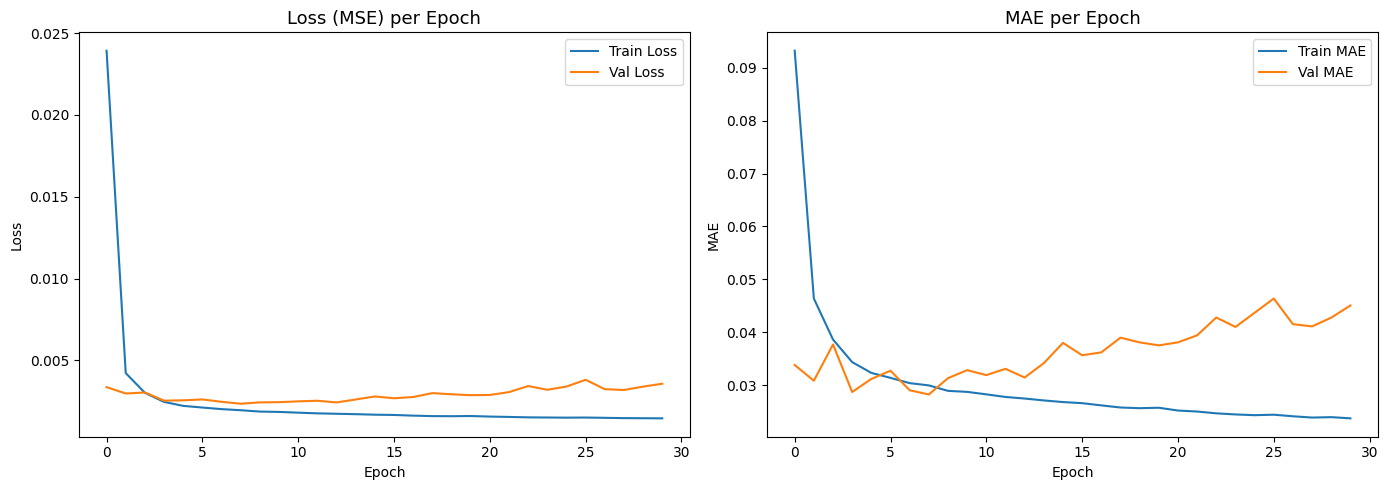

In [10]:
# Visualisasi Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (MSE) per Epoch', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['train_mae'], label='Train MAE')
axes[1].plot(history['val_mae'], label='Val MAE')
axes[1].set_title('MAE per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

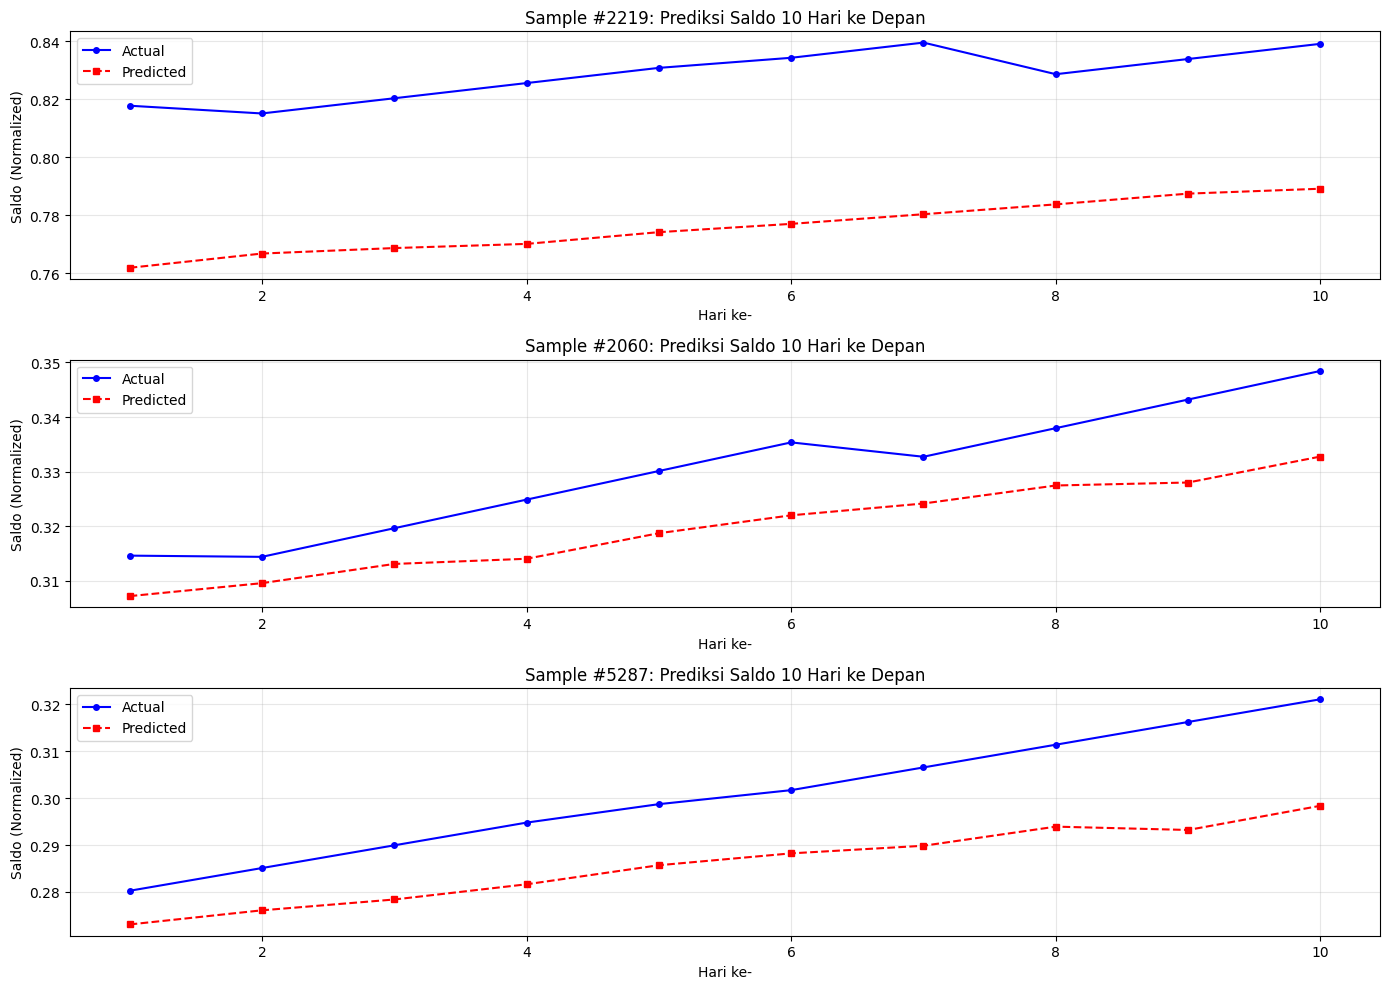

In [11]:
# Visualisasi Actual vs Predicted (sample 3 sequence)
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for i in range(3):
    idx = np.random.randint(0, len(X_test))
    days = range(1, FORECAST + 1)
    axes[i].plot(days, y_test[idx], 'b-o', label='Actual', markersize=4)
    axes[i].plot(days, y_pred[idx], 'r--s', label='Predicted', markersize=4)
    axes[i].set_title(f'Sample #{idx}: Prediksi Saldo 10 Hari ke Depan', fontsize=12)
    axes[i].set_xlabel('Hari ke-')
    axes[i].set_ylabel('Saldo (Normalized)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Early Warning Logic

Jika prediksi saldo pada salah satu dari 10 hari ke depan bernilai < 0 (setelah inverse transform), maka sistem memicu **notifikasi preventif**.

In [12]:
def check_early_warning(predictions, threshold=0.1):
    """
    Cek apakah ada hari dengan saldo diprediksi rendah.
    threshold: batas saldo normalized di bawah mana dianggap berbahaya.
    Karena data sudah di-normalize (0-1), threshold 0.1 berarti saldo
    mendekati nilai minimum historis.
    """
    warnings = []
    for day_idx, val in enumerate(predictions):
        if val < threshold:
            warnings.append({
                'hari_ke': day_idx + 1,
                'prediksi_saldo_normalized': float(val),
                'status': 'BAHAYA' if val < 0.05 else 'WARNING'
            })
    return warnings

# Demo: cek beberapa sample dari test set
print('=== Demo Early Warning System ===')
warning_count = 0
for i in range(min(20, len(y_pred))):
    alerts = check_early_warning(y_pred[i])
    if alerts:
        warning_count += 1
        print(f'\nSequence #{i}: ALERT TERDETEKSI!')
        for a in alerts:
            print(f"  Hari ke-{a['hari_ke']}: Saldo={a['prediksi_saldo_normalized']:.4f} [{a['status']}]")

if warning_count == 0:
    print('Tidak ada warning terdeteksi pada 20 sample pertama.')
    print('(Ini normal jika mayoritas user memiliki saldo sehat)')

=== Demo Early Warning System ===

Sequence #0: ALERT TERDETEKSI!
  Hari ke-1: Saldo=0.0774 [WARNING]
  Hari ke-2: Saldo=0.0871 [WARNING]
  Hari ke-3: Saldo=0.0895 [WARNING]
  Hari ke-4: Saldo=0.0836 [WARNING]
  Hari ke-5: Saldo=0.0924 [WARNING]
  Hari ke-6: Saldo=0.0936 [WARNING]
  Hari ke-7: Saldo=0.0952 [WARNING]

Sequence #1: ALERT TERDETEKSI!
  Hari ke-1: Saldo=0.0815 [WARNING]
  Hari ke-2: Saldo=0.0913 [WARNING]
  Hari ke-3: Saldo=0.0930 [WARNING]
  Hari ke-4: Saldo=0.0891 [WARNING]
  Hari ke-5: Saldo=0.0963 [WARNING]
  Hari ke-6: Saldo=0.0976 [WARNING]
  Hari ke-7: Saldo=0.0996 [WARNING]

Sequence #2: ALERT TERDETEKSI!
  Hari ke-1: Saldo=0.0852 [WARNING]
  Hari ke-2: Saldo=0.0943 [WARNING]
  Hari ke-3: Saldo=0.0960 [WARNING]
  Hari ke-4: Saldo=0.0931 [WARNING]
  Hari ke-5: Saldo=0.0996 [WARNING]

Sequence #3: ALERT TERDETEKSI!
  Hari ke-1: Saldo=0.0832 [WARNING]
  Hari ke-2: Saldo=0.0902 [WARNING]
  Hari ke-3: Saldo=0.0935 [WARNING]
  Hari ke-4: Saldo=0.0879 [WARNING]
  Hari ke-

## 7. Save Model & Scaler

In [13]:
# Buat folder jika belum ada
os.makedirs('models/saved', exist_ok=True)

# Save model
model.save('models/saved/lstm_model.keras')
print('Model LSTM berhasil disimpan ke models/saved/lstm_model.keras')

# Save scaler
with open('models/saved/lstm_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler berhasil disimpan ke models/saved/lstm_scaler.pkl')

# Save config
config = {'LOOKBACK': LOOKBACK, 'FORECAST': FORECAST, 'FEATURES': FEATURES, 'TARGET': TARGET}
with open('models/saved/lstm_config.pkl', 'wb') as f:
    pickle.dump(config, f)
print('Config berhasil disimpan ke models/saved/lstm_config.pkl')

Model LSTM berhasil disimpan ke models/saved/lstm_model.keras
Scaler berhasil disimpan ke models/saved/lstm_scaler.pkl
Config berhasil disimpan ke models/saved/lstm_config.pkl


## Insight

Model LSTM Early Warning System ini mampu memprediksi tren saldo keuangan pengguna 10 hari ke depan berdasarkan pola pengeluaran 30 hari terakhir.

Dengan custom training loop menggunakan `tf.GradientTape`, kita mendapat kontrol penuh atas proses training dan dapat melacak metrik secara detail melalui TensorBoard.

Fitur ini menjadi **"rem darurat"** bagi pengguna Gen-Z sebelum saldo mereka benar-benar habis, sesuai dengan tujuan utama A.L.I.C.E sebagai sistem navigasi keuangan preventif.